<a href="https://colab.research.google.com/github/rizwinmk/ICT_DSA_NOTES/blob/main/Exit_exam_G3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv("/content/G3.csv")

In [3]:
df.head()

,enterprise_group_id,display_name,enterprise_group_name,group_root_lei,enterprise_group_jurisdiction,enterprise_group_entity_status,website,company_type,employees,employees_year,...,market_cap_date,legal_units_count,direct_subsidiaries_count,max_hierarchy_depth,is_standalone_entity,website_source,employees_source,revenue_source,net_income_source,market_cap_source
0,EG_03260722,Morgan Stanley,MORGAN STANLEY,IGJSJL3JD5P30I6NJZ34,US-DE,ACTIVE,morganstanley.com,PUBLIC,83000.0,2025.0,...,2025-12-31,1013,173.0,8.0,False,morganstanley.com,sec.gov,sec.gov,sec.gov,finance.yahoo.com
1,EG_03256960,Bank of America,BANK OF AMERICA CORPORATION,9DJT3UXIJIZJI4WXO774,US-DE,ACTIVE,bankofamerica.com,PUBLIC,213000.0,2025.0,...,2025-12-31,761,155.0,5.0,False,bankofamerica.com,sec.gov,sec.gov,https://investor.bankofamerica.com/regulatory-...,macrotrends.net
2,EG_01804232,Citigroup,CITIGROUP INC.,6SHGI4ZSSLCXXQSBB395,US-DE,ACTIVE,citigroup.com,PUBLIC,226000.0,2025.0,...,2025-12-31,742,22.0,9.0,False,citigroup.com,sec.gov,tradingview.com,tradingview.com,uk.finance.yahoo.com
3,EG_02027196,Goldman Sachs,"THE GOLDMAN SACHS GROUP, INC.",784F5XWPLTWKTBV3E584,US-DE,ACTIVE,https://www.goldmansachs.com,PUBLIC,47400.0,2025.0,...,2025-12-31,568,190.0,7.0,False,goldmansachs.com,sec.gov,goldmansachs.com,goldmansachs.com,finance.yahoo.com
4,EG_03266820,Siemens,Siemens Aktiengesellschaft,W38RGI023J3WT1HWRP32,DE,ACTIVE,siemens.com,PUBLIC,318000.0,2025.0,...,2025-09-30,568,454.0,3.0,False,siemens.com,siemens.com,siemens.com,siemens.com,siemens.com


In [6]:
df.describe()

,employees,employees_year,revenue,revenue_year,net_income,net_income_year,market_cap,legal_units_count,direct_subsidiaries_count,max_hierarchy_depth
count,1.656000e+03,1655.000000,1.654000e+03,1653.000000,1.599000e+03,1599.000000,1.224000e+03,1755.000000,1747.000000,1747.000000
mean,3.989013e+04,2024.951057,9.050901e+11,2024.923775,7.895350e+10,2024.914321,2.057347e+12,34.330484,17.531196,2.038351
std,9.625128e+04,0.312028,1.080451e+13,0.441763,1.216758e+12,0.459405,4.925187e+13,58.980527,27.903769,1.044385
min,0.000000e+00,2023.000000,-3.518000e+09,2012.000000,-1.060000e+12,2012.000000,8.270000e+06,1.000000,0.000000,0.000000
25%,2.521750e+03,2025.000000,2.198500e+09,2025.000000,5.681000e+07,2025.000000,3.600000e+09,11.000000,5.000000,1.000000
50%,1.230000e+04,2025.000000,9.247250e+09,2025.000000,5.889000e+08,2025.000000,1.936500e+10,18.000000,9.000000,2.000000
75%,3.875725e+04,2025.000000,3.478425e+10,2025.000000,3.414500e+09,2025.000000,8.876100e+10,35.000000,18.000000,2.000000
max,2.100000e+06,2026.000000,3.336000e+14,2026.000000,4.520000e+13,2026.000000,1.716780e+15,1013.000000,454.000000,9.000000


In [8]:
numerical_features = df.select_dtypes(include=["number"]).columns.tolist()

In [9]:
categorical_features = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()


In [10]:

print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)

Numerical Features: ['employees', 'employees_year', 'revenue', 'revenue_year', 'net_income', 'net_income_year', 'market_cap', 'legal_units_count', 'direct_subsidiaries_count', 'max_hierarchy_depth']
Categorical Features: ['enterprise_group_id', 'display_name', 'enterprise_group_name', 'group_root_lei', 'enterprise_group_jurisdiction', 'enterprise_group_entity_status', 'website', 'company_type', 'revenue_currency', 'net_income_currency', 'market_cap_currency', 'market_cap_date', 'website_source', 'employees_source', 'revenue_source', 'net_income_source', 'market_cap_source']


In [11]:
df.isnull().sum()

,0
enterprise_group_id,0
display_name,0
enterprise_group_name,0
group_root_lei,0
enterprise_group_jurisdiction,0
enterprise_group_entity_status,0
website,39
company_type,2
employees,99
employees_year,100


In [13]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage

,0
enterprise_group_id,0.000000
display_name,0.000000
enterprise_group_name,0.000000
group_root_lei,0.000000
enterprise_group_jurisdiction,0.000000
enterprise_group_entity_status,0.000000
website,2.222222
company_type,0.113960
employees,5.641026
employees_year,5.698006


In [14]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

duplicate_rows = df[df.duplicated(keep=False)]
print("\nDuplicate records:")
display(duplicate_rows)

Number of duplicate rows: 0

Duplicate records:


,enterprise_group_id,display_name,enterprise_group_name,group_root_lei,enterprise_group_jurisdiction,enterprise_group_entity_status,website,company_type,employees,employees_year,...,market_cap_date,legal_units_count,direct_subsidiaries_count,max_hierarchy_depth,is_standalone_entity,website_source,employees_source,revenue_source,net_income_source,market_cap_source


In [15]:
revenue_column = "revenue"
df[revenue_column] = pd.to_numeric(df[revenue_column], errors="coerce")


revenue_summary = df[revenue_column].describe()

print("Revenue summary statistics:")
print(revenue_summary)

Revenue summary statistics:
count    1.654000e+03
mean     9.050901e+11
std      1.080451e+13
min     -3.518000e+09
25%      2.198500e+09
50%      9.247250e+09
75%      3.478425e+10
max      3.336000e+14
Name: revenue, dtype: float64



Additional statistics:
Missing values: 101
Unique values: 1612
Skewness: 22.68
Kurtosis: 613.06


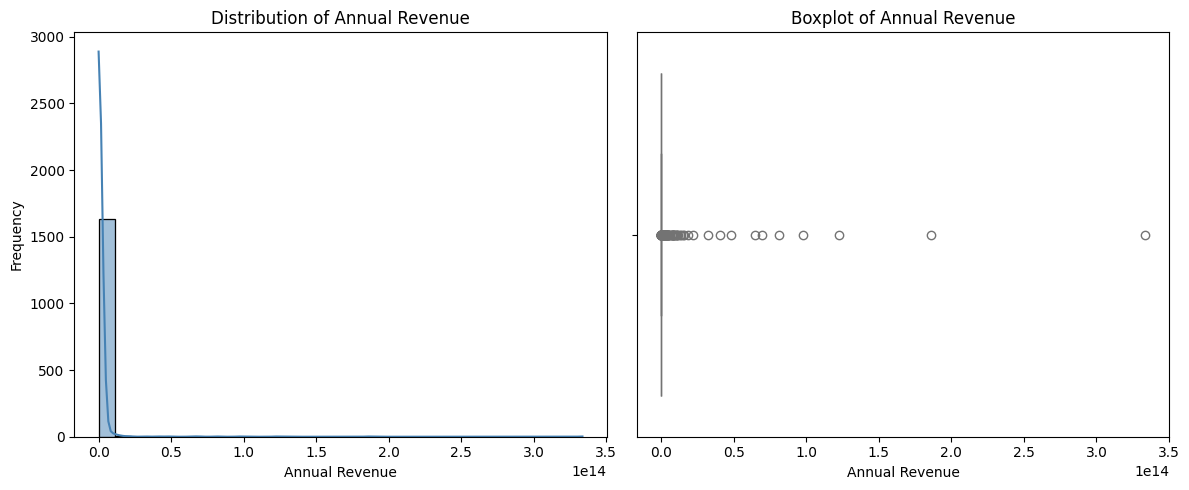

In [17]:
revenue_data = df[df[revenue_column].notna() & (df[revenue_column] >= 0)]
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(
    data=revenue_data,
    x=revenue_column,
    bins=30,
    kde=True,
    color="steelblue"
)
plt.title("Distribution of Annual Revenue")
plt.xlabel("Annual Revenue")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(
    data=revenue_data,
    x=revenue_column,
    color="lightgreen"
)
plt.title("Boxplot of Annual Revenue")
plt.xlabel("Annual Revenue")

plt.tight_layout()
plt.show()

1.Overall enterprise revenue distribution:
count    1.652000e+03
mean     9.061880e+11
std      1.081101e+13
min      0.000000e+00
25%      2.200000e+09
50%      9.311500e+09
75%      3.489275e+10
max      3.336000e+14

2.market_cap


TASK 2

In [48]:
df.isnull().sum()

,0
enterprise_group_id,0
display_name,0
enterprise_group_name,0
group_root_lei,0
enterprise_group_jurisdiction,0
enterprise_group_entity_status,0
website,0
company_type,0
employees,0
employees_year,0


In [32]:

df["website"] = df["website"].fillna("Unknown")


df["website"] = (
    df["website"]
    .astype("string")
    .str.strip()
    .replace("", pd.NA)
    .fillna("Unknown")
)

print(df["website"].isnull().sum())
print(df["website"].value_counts().head())

0
website
Unknown                       39
https://www.lgt.com/           2
https://www.ubs.com            2
https://www.mzb-group.com/     2
https://global.abb             2
Name: count, dtype: Int64


In [41]:
df["company_type"] = df["company_type"].fillna("Unknown")

In [45]:
for column in numerical_features:
    df[column] = pd.to_numeric(df[column], errors="coerce")
    df[column] = df[column].fillna(df[column].median())

In [47]:
for column in categorical_features:
    df[column] = (
        df[column]
        .astype("string")
        .str.strip()
        .replace("", pd.NA)
        .fillna("Unknown")
    )


In [50]:
from sklearn.preprocessing import OneHotEncoder


encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)


encoded_categories = encoder.fit_transform(
    df[categorical_features]
)

encoded_df = pd.DataFrame(
    encoded_categories,
    columns=encoder.get_feature_names_out(categorical_features),
    index=df.index
)

df_encoded = pd.concat(
    [
        df[numerical_features],
        encoded_df
    ],
    axis=1
)

print("Encoded dataset shape:", df_encoded.shape)
display(df_encoded.tail())

Encoded dataset shape: (1755, 16111)


,employees,employees_year,revenue,revenue_year,net_income,net_income_year,market_cap,legal_units_count,direct_subsidiaries_count,max_hierarchy_depth,...,market_cap_source_valmet.com,market_cap_source_veolia.com,market_cap_source_verbund.com,market_cap_source_voltalia.com,market_cap_source_web.energy,market_cap_source_wienerberger.com,market_cap_source_worldline.com,market_cap_source_wtwco.com,market_cap_source_yahoo.com,market_cap_source_yahoo.jp
1750,5000.0,2025.0,4.691800e+10,2025.0,3.268000e+09,2025.0,6.380000e+10,4,3.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1751,12737.0,2025.0,1.471120e+10,2025.0,5.263000e+08,2025.0,9.000000e+09,4,2.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1752,5535.0,2025.0,3.675900e+09,2025.0,4.435000e+08,2025.0,1.500000e+10,4,1.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1753,6343.0,2025.0,2.535400e+09,2025.0,6.722000e+08,2025.0,1.045000e+10,4,2.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1754,5533.0,2025.0,3.718800e+09,2025.0,1.330100e+09,2025.0,1.936500e+10,1,93.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [51]:

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, mutual_info_regression

# Set the target column
target_column = "revenue"

# Prepare target variable
y = pd.to_numeric(df[target_column], errors="coerce")

# Keep rows with valid revenue values
valid_rows = y.notna() & (y >= 0)

# Use the encoded feature dataset
X = df_encoded.loc[valid_rows].copy()
y = y.loc[valid_rows]

# Remove any accidental target column from the features
X = X.drop(columns=[target_column], errors="ignore")

# Split data before feature selection
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Select the top features
number_of_features = min(20, X_train.shape[1])

selector = SelectKBest(
    score_func=mutual_info_regression,
    k=number_of_features
)

X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Get selected feature names
selected_features = X_train.columns[selector.get_support()].tolist()

print("Selected features:")
print(selected_features)

print("\nNumber of selected features:", len(selected_features))

# Create selected feature DataFrames
X_train_selected = pd.DataFrame(
    X_train_selected,
    columns=selected_features,
    index=X_train.index
)

X_test_selected = pd.DataFrame(
    X_test_selected,
    columns=selected_features,
    index=X_test.index
)

# Display feature scores
feature_scores = pd.DataFrame({
    "feature": X_train.columns,
    "score": selector.scores_
}).sort_values(
    by="score",
    ascending=False
)

print("\nFeature importance scores:")
display(feature_scores.head(number_of_features))

Selected features:
['employees', 'revenue_year', 'net_income', 'market_cap', 'direct_subsidiaries_count', 'enterprise_group_jurisdiction_JP', 'company_type_PRIVATE', 'company_type_PUBLIC', 'revenue_currency_EUR', 'revenue_currency_JPY', 'revenue_currency_Unknown', 'net_income_currency_EUR', 'net_income_currency_JPY', 'net_income_currency_Unknown', 'market_cap_currency_JPY', 'market_cap_currency_Unknown', 'market_cap_date_Unknown', 'revenue_source_Unknown', 'net_income_source_Unknown', 'market_cap_source_Unknown']

Number of selected features: 20

Feature importance scores:


,feature,score
3,net_income,0.692346
5,market_cap,0.536775
0,employees,0.371325
8883,revenue_currency_Unknown,0.199645
12182,revenue_source_Unknown,0.145772
8842,company_type_PRIVATE,0.123750
8843,company_type_PUBLIC,0.121617
7065,enterprise_group_jurisdiction_JP,0.117539
8953,market_cap_currency_Unknown,0.116752
8864,revenue_currency_JPY,0.114461


In [52]:
feature_scores[
    feature_scores["feature"].str.contains("Unknown", case=False, na=False)
]

,feature,score
8883,revenue_currency_Unknown,0.199645
12182,revenue_source_Unknown,0.145772
8953,market_cap_currency_Unknown,0.116752
9048,market_cap_date_Unknown,0.111980
8919,net_income_currency_Unknown,0.100584
15125,market_cap_source_Unknown,0.099384
13674,net_income_source_Unknown,0.079759
10752,employees_source_Unknown,0.065369
7128,website_Unknown,0.043249
9050,website_source_Unknown,0.031722


In [54]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import SelectKBest, mutual_info_regression


target_column = "revenue"


df[target_column] = pd.to_numeric(
    df[target_column],
    errors="coerce"
)


valid_rows = (
    df[target_column].notna()
    & (df[target_column] >= 0)
)


y = df.loc[valid_rows, target_column]


X = df_encoded.loc[valid_rows].copy()


columns_to_remove = [
    target_column,
    "revenue_source",
    "revenue_currency"
]

X = X.drop(
    columns=[
        column for column in columns_to_remove
        if column in X.columns
    ],
    errors="ignore"
)


X = X.drop(
    columns=[
        column for column in X.columns
        if column.startswith("revenue_source_")
        or column.startswith("revenue_currency_")
    ],
    errors="ignore"
)


X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

number_of_features = min(20, X.shape[1])

selector = SelectKBest(
    score_func=mutual_info_regression,
    k=number_of_features
)

selector.fit(X, y)

selected_features = X.columns[selector.get_support()].tolist()

removed_features = X.columns[
    ~selector.get_support()
].tolist()


print("Selected features:")
for feature in selected_features:
    print(feature)

print("\nNumber of selected features:", len(selected_features))


print("\nRemoved features:")
for feature in removed_features:
    print(feature)

print("\nNumber of removed features:", len(removed_features))


feature_scores = pd.DataFrame({
    "feature": X.columns,
    "score": selector.scores_,
    "selected": selector.get_support()
}).sort_values(
    by="score",
    ascending=False
)

print("\nFeature scores:")
display(feature_scores)


X_selected = X[selected_features]

print("\nSelected feature dataset shape:")
print(X_selected.shape)

Selected features:
employees
revenue_year
net_income
market_cap
direct_subsidiaries_count
enterprise_group_jurisdiction_JP
website_Unknown
company_type_PRIVATE
company_type_PUBLIC
net_income_currency_EUR
net_income_currency_JPY
net_income_currency_USD
net_income_currency_Unknown
market_cap_currency_JPY
market_cap_currency_USD
market_cap_currency_Unknown
market_cap_date_Unknown
employees_source_Unknown
net_income_source_Unknown
market_cap_source_Unknown

Number of selected features: 20

Removed features:
employees_year
net_income_year
legal_units_count
max_hierarchy_depth
enterprise_group_id_EG_00000699
enterprise_group_id_EG_00005692
enterprise_group_id_EG_00005717
enterprise_group_id_EG_00005845
enterprise_group_id_EG_00005915
enterprise_group_id_EG_00006023
enterprise_group_id_EG_00006080
enterprise_group_id_EG_00010782
enterprise_group_id_EG_00011095
enterprise_group_id_EG_00011114
enterprise_group_id_EG_00011690
enterprise_group_id_EG_00012430
enterprise_group_id_EG_00012949
enterp

,feature,score,selected
3,net_income,0.715148,True
5,market_cap,0.527778,True
0,employees,0.410751,True
8843,company_type_PUBLIC,0.134456,True
8917,market_cap_currency_Unknown,0.131354,True
...,...,...,...
9486,website_source_https://www.aep.com/,0.000000,False
9485,website_source_https://www.aecom.com,0.000000,False
9484,website_source_https://www.adyen.com,0.000000,False
9480,website_source_https://www.adeccogroup.com,0.000000,False



Selected feature dataset shape:
(1753, 20)


In [83]:
import pickle


artifacts = {
    "selector": selector,
    "selected_features": selected_features,

}

with open("model_artifacts.pkl", "wb") as f:
    pickle.dump(artifacts, f)

print("Artifacts successfully saved to model_artifacts.pkl!")

Artifacts successfully saved to model_artifacts.pkl!


In [55]:

target_column = "revenue"


df[target_column] = pd.to_numeric(
    df[target_column],
    errors="coerce"
)


valid_rows = (
    df[target_column].notna()
    & (df[target_column] >= 0)
)


y = df.loc[valid_rows, target_column].copy()


X = df_encoded.loc[valid_rows, selected_features].copy()

X = X.replace([np.inf, -np.inf], np.nan)


X = X.fillna(X.median())


X = X.fillna(0)

constant_columns = X.columns[X.nunique() <= 1].tolist()

if constant_columns:
    X = X.drop(columns=constant_columns)


X = X.reset_index(drop=True)
y = y.reset_index(drop=True)


print("Feature dataset shape:", X.shape)
print("Target dataset shape:", y.shape)

print("\nRemaining missing values:")
print(X.isnull().sum().sum())

print("\nRemaining infinite values:")
print(np.isinf(X.select_dtypes(include=np.number)).sum().sum())

print("\nFeature columns prepared for modeling:")
print(X.columns.tolist())

print("\nTarget summary:")
print(y.describe())

Feature dataset shape: (1753, 20)
Target dataset shape: (1753,)

Remaining missing values:
0

Remaining infinite values:
0

Feature columns prepared for modeling:
['employees', 'revenue_year', 'net_income', 'market_cap', 'direct_subsidiaries_count', 'enterprise_group_jurisdiction_JP', 'website_Unknown', 'company_type_PRIVATE', 'company_type_PUBLIC', 'net_income_currency_EUR', 'net_income_currency_JPY', 'net_income_currency_USD', 'net_income_currency_Unknown', 'market_cap_currency_JPY', 'market_cap_currency_USD', 'market_cap_currency_Unknown', 'market_cap_date_Unknown', 'employees_source_Unknown', 'net_income_source_Unknown', 'market_cap_source_Unknown']

Target summary:
count    1.753000e+03
mean     8.545103e+11
std      1.049684e+13
min      0.000000e+00
25%      2.455000e+09
50%      9.247250e+09
75%      3.244700e+10
max      3.336000e+14
Name: revenue, dtype: float64


1.Identify the target variable
 handle missing values
 Encode categorical variables
 Remove irrelevant or leaking columns
 Handle invalid numerical values
 Select relevant features
 Check the final dataset
  prepared modeling data
2.Encoding categorical variables was necessary because machine-learning models work with numbers not texts.

TASK 3


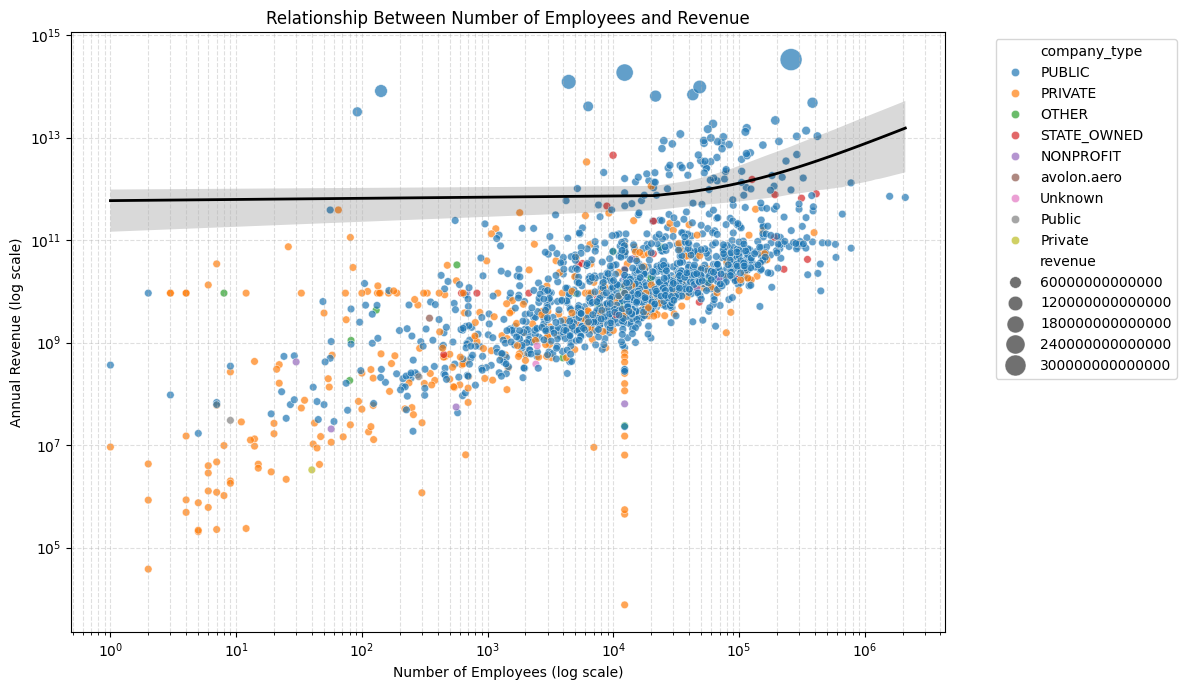

In [73]:



plot_df = df[["employees", "revenue", "company_type"]].copy()


plot_df["employees"] = pd.to_numeric(
    plot_df["employees"],
    errors="coerce"
)

plot_df["revenue"] = pd.to_numeric(
    plot_df["revenue"],
    errors="coerce"
)


plot_df = plot_df.dropna(
    subset=["employees", "revenue"]
)

plot_df = plot_df[
    (plot_df["employees"] > 0) &
    (plot_df["revenue"] > 0)
]


plot_df["company_type"] = (
    plot_df["company_type"]
    .fillna("Unknown")
    .astype(str)
)


plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=plot_df,
    x="employees",
    y="revenue",
    hue="company_type",
    size="revenue",
    sizes=(30, 250),
    alpha=0.7
)


sns.regplot(
    data=plot_df,
    x="employees",
    y="revenue",
    scatter=False,
    color="black",
    line_kws={"linewidth": 2, "label": "Overall trend"}
)


plt.xscale("log")
plt.yscale("log")

plt.title("Relationship Between Number of Employees and Revenue")
plt.xlabel("Number of Employees (log scale)")
plt.ylabel("Annual Revenue (log scale)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

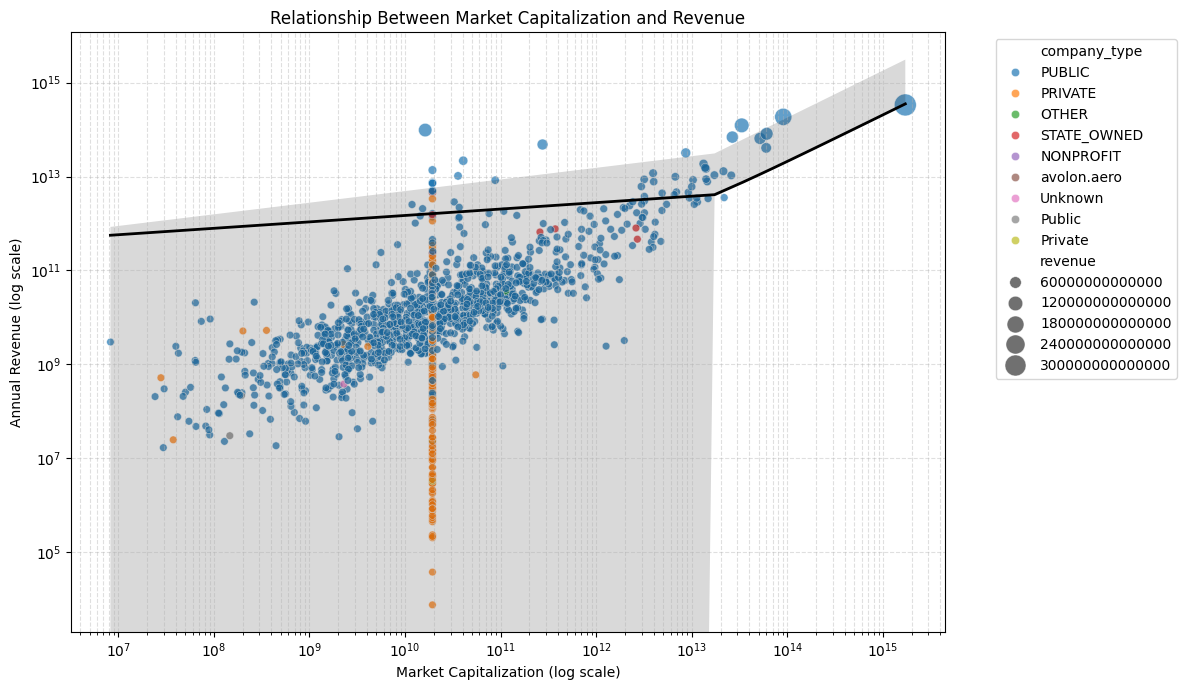

In [75]:

plot_df = df[["market_cap", "revenue", "company_type"]].copy()


plot_df["market_cap"] = pd.to_numeric(plot_df["market_cap"], errors="coerce")
plot_df["revenue"] = pd.to_numeric(plot_df["revenue"], errors="coerce")


plot_df = plot_df.dropna(subset=["market_cap", "revenue"])
plot_df = plot_df[(plot_df["market_cap"] > 0) & (plot_df["revenue"] > 0)]

plot_df["company_type"] = (
    plot_df["company_type"]
    .fillna("Unknown")
    .astype(str)
)


plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=plot_df,
    x="market_cap",
    y="revenue",
    hue="company_type",
    size="revenue",
    sizes=(30, 250),
    alpha=0.7
)

sns.regplot(
    data=plot_df,
    x="market_cap",
    y="revenue",
    scatter=False,
    color="black",
    line_kws={"linewidth": 2}
)

plt.xscale("log")
plt.yscale("log")

plt.title("Relationship Between Market Capitalization and Revenue")
plt.xlabel("Market Capitalization (log scale)")
plt.ylabel("Annual Revenue (log scale)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


/tmp/ipykernel_6223/1072860920.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


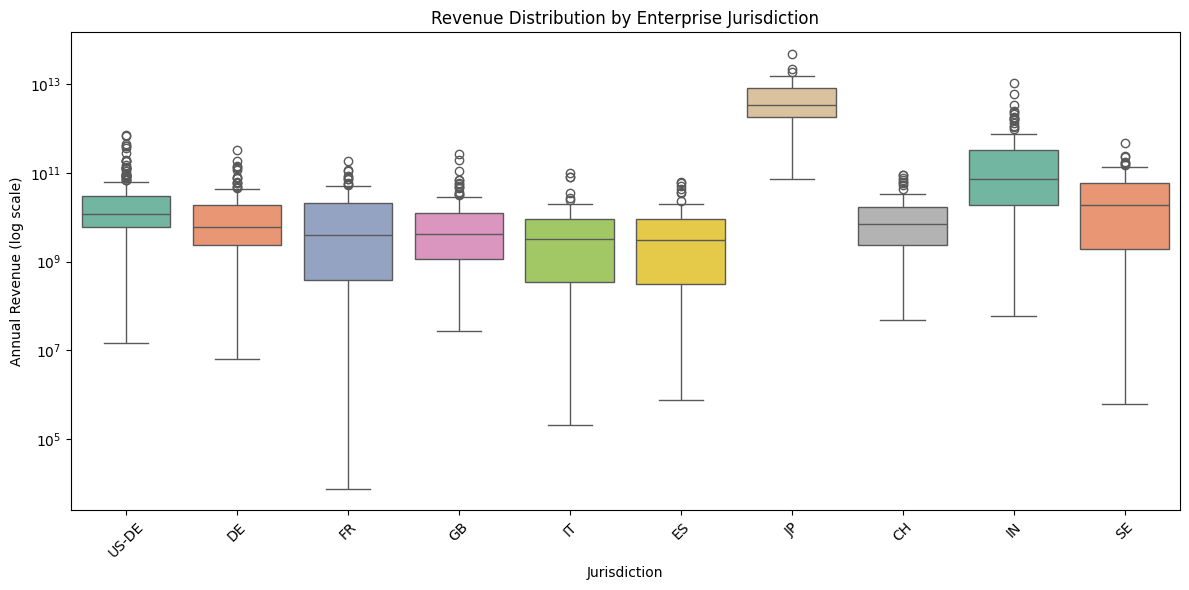

Revenue summary by jurisdiction:


,count,mean,median,max
enterprise_group_jurisdiction,,,,
JP,55,6.070420e+12,3.400539e+12,4.803670e+13
IN,105,4.894503e+11,7.421650e+10,1.071174e+13
SE,72,4.722065e+10,1.873100e+10,4.791830e+11
US-DE,254,3.786290e+10,1.193765e+10,7.169240e+11
DE,141,1.933175e+10,6.083000e+09,3.219130e+11
CH,60,1.639792e+10,7.170000e+09,8.949000e+10
FR,128,1.582023e+10,4.030000e+09,1.823440e+11
GB,122,1.446054e+10,4.128000e+09,2.669000e+11
IT,67,9.515827e+09,3.176000e+09,9.812400e+10


In [76]:


plot_df = df[["enterprise_group_jurisdiction", "revenue"]].copy()


plot_df["revenue"] = pd.to_numeric(plot_df["revenue"], errors="coerce")

plot_df = plot_df.dropna(subset=["enterprise_group_jurisdiction", "revenue"])
plot_df = plot_df[plot_df["revenue"] > 0]

plot_df["enterprise_group_jurisdiction"] = (
    plot_df["enterprise_group_jurisdiction"]
    .fillna("Unknown")
    .astype(str)
)


top_jurisdictions = (
    plot_df["enterprise_group_jurisdiction"]
    .value_counts()
    .head(10)
    .index
)

plot_df = plot_df[
    plot_df["enterprise_group_jurisdiction"].isin(top_jurisdictions)
]


plt.figure(figsize=(12, 6))

sns.boxplot(
    data=plot_df,
    x="enterprise_group_jurisdiction",
    y="revenue",
    palette="Set2"
)

plt.yscale("log")

plt.title("Revenue Distribution by Enterprise Jurisdiction")
plt.xlabel("Jurisdiction")
plt.ylabel("Annual Revenue (log scale)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


summary = (
    plot_df.groupby("enterprise_group_jurisdiction")["revenue"]
    .agg(["count", "mean", "median", "max"])
    .sort_values("mean", ascending=False)
)

print("Revenue summary by jurisdiction:")
display(summary)

/tmp/ipykernel_6223/2003917165.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


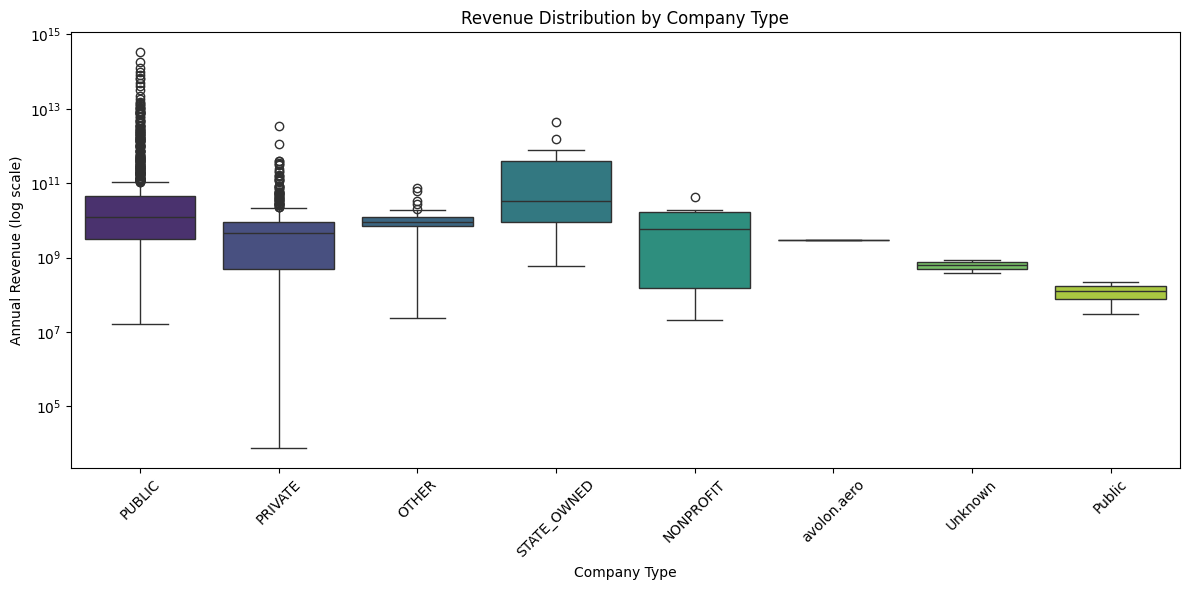

Revenue summary by company type:


,count,mean,median,max
company_type,,,,
PUBLIC,1280,1.153565e+12,1.211050e+10,3.336000e+14
STATE_OWNED,22,4.266146e+11,3.416250e+10,4.533736e+12
PRIVATE,396,2.895851e+10,4.482885e+09,3.355916e+12
OTHER,32,1.350402e+10,9.247250e+09,7.320000e+10
NONPROFIT,10,1.039051e+10,5.722625e+09,4.330000e+10
avolon.aero,1,3.000000e+09,3.000000e+09,3.000000e+09
Unknown,2,6.212500e+08,6.212500e+08,8.606000e+08
Public,2,1.235870e+08,1.235870e+08,2.167350e+08


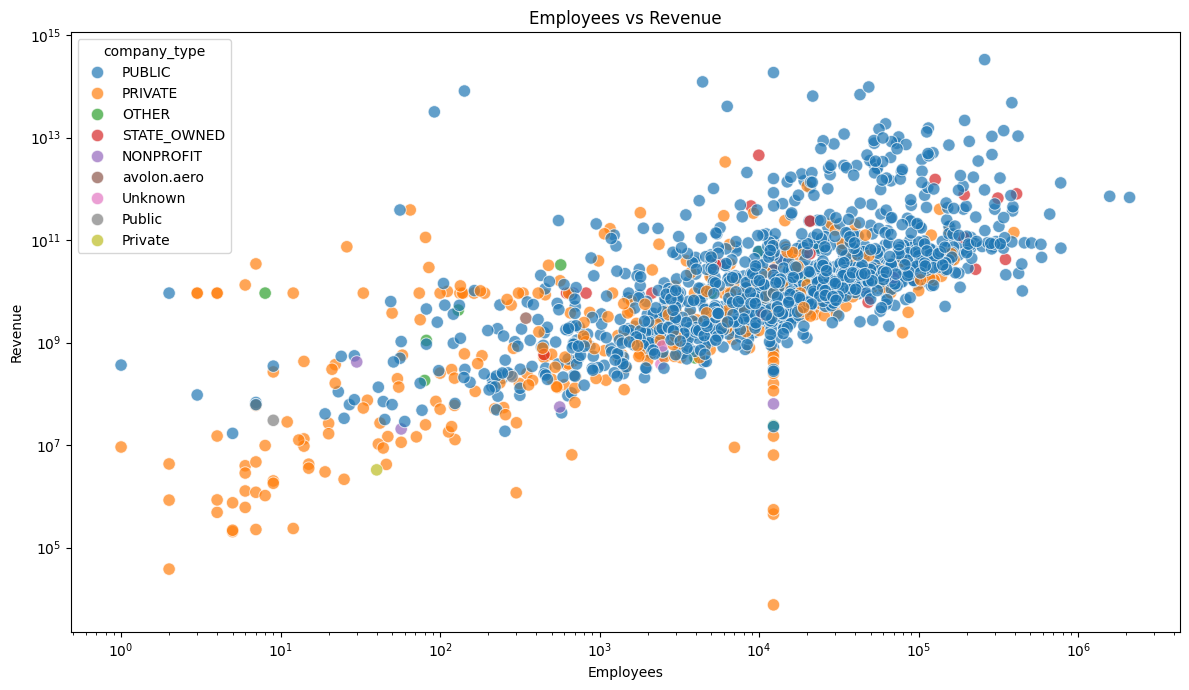

In [77]:



plot_df = df[["company_type", "revenue"]].copy()


plot_df["revenue"] = pd.to_numeric(plot_df["revenue"], errors="coerce")


plot_df = plot_df.dropna(subset=["company_type", "revenue"])
plot_df = plot_df[plot_df["revenue"] > 0]


plot_df["company_type"] = (
    plot_df["company_type"]
    .fillna("Unknown")
    .astype(str)
)

top_types = (
    plot_df["company_type"]
    .value_counts()
    .head(8)
    .index
)

plot_df = plot_df[
    plot_df["company_type"].isin(top_types)
]


plt.figure(figsize=(12, 6))

sns.boxplot(
    data=plot_df,
    x="company_type",
    y="revenue",
    palette="viridis"
)

plt.yscale("log")

plt.title("Revenue Distribution by Company Type")
plt.xlabel("Company Type")
plt.ylabel("Annual Revenue (log scale)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

summary = (
    plot_df.groupby("company_type")["revenue"]
    .agg(["count", "mean", "median", "max"])
    .sort_values("mean", ascending=False)
)

print("Revenue summary by company type:")
display(summary)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = df[["employees", "revenue", "company_type"]].copy()


plot_df["employees"] = pd.to_numeric(plot_df["employees"], errors="coerce")
plot_df["revenue"] = pd.to_numeric(plot_df["revenue"], errors="coerce")


plot_df = plot_df.dropna(subset=["employees", "revenue"])
plot_df = plot_df[(plot_df["employees"] > 0) & (plot_df["revenue"] > 0)]

plot_df["company_type"] = (
    plot_df["company_type"]
    .fillna("Unknown")
    .astype(str)
)

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=plot_df,
    x="employees",
    y="revenue",
    hue="company_type",
    alpha=0.7,
    s=80
)


plt.xscale("log")
plt.yscale("log")

plt.title("Employees vs Revenue")
plt.xlabel("Employees")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

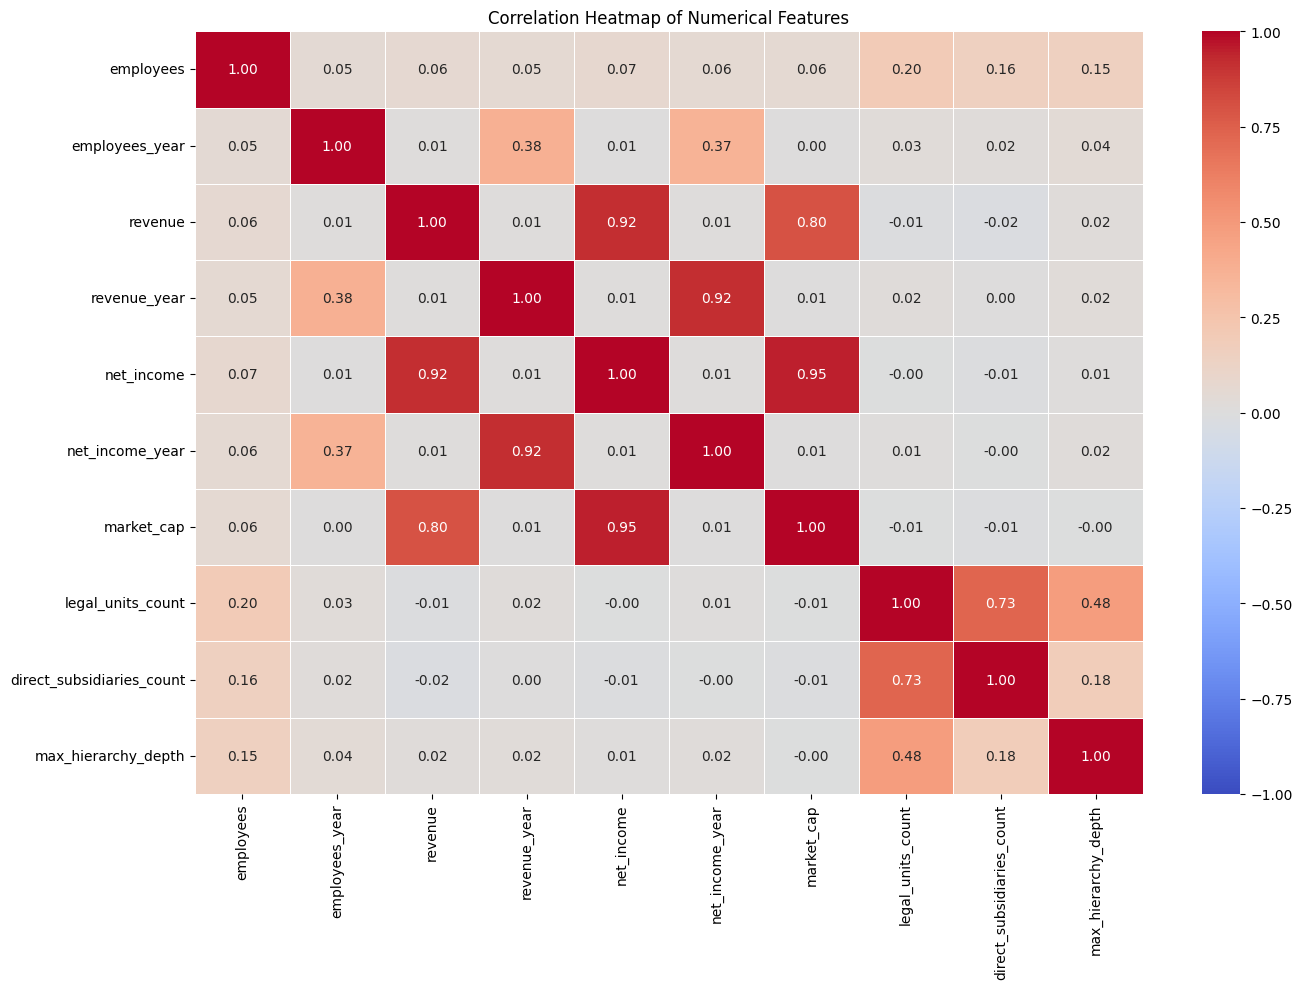

Correlation with revenue:
revenue                      1.000000
net_income                   0.917543
market_cap                   0.801791
employees                    0.063106
max_hierarchy_depth          0.017045
net_income_year              0.014020
revenue_year                 0.013003
employees_year               0.011128
legal_units_count           -0.011595
direct_subsidiaries_count   -0.016302
Name: revenue, dtype: float64


In [78]:

numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()

relevant_numeric = [
    col for col in numeric_cols
    if col not in ["enterprise_group_id"]
]


corr_df = df[relevant_numeric].copy()


for col in corr_df.columns:
    corr_df[col] = pd.to_numeric(corr_df[col], errors="coerce")

corr_df = corr_df.dropna()


corr_matrix = corr_df.corr(method="pearson")

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()


if "revenue" in corr_df.columns:
    revenue_corr = corr_df.corr()["revenue"].sort_values(ascending=False)
    print("Correlation with revenue:")
    print(revenue_corr)

1.yes strong positive one the more employee a company has the more revenue it generates

2.does not directly influence revenue  instead, it is usually a reflection of it

3.Market Capitalization and Total Employees are the strongest predictors

TASK 4

In [79]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


target_column = "revenue"
valid_mask = df[target_column].notna() & (df[target_column] >= 0)
y = df.loc[valid_mask, target_column]


features_to_drop = [target_column, "revenue_source", "revenue_currency", "revenue_year"]
X = df_encoded.loc[valid_mask].copy()
X = X.drop(columns=[col for col in features_to_drop if col in X.columns], errors="ignore")
X = X.drop(columns=[col for col in X.columns if col.startswith("revenue_source_") or col.startswith("revenue_currency_")], errors="ignore")
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


In [80]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = []

for name, y_pred in predictions.items():
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R² Score": r2
    })


results_df = pd.DataFrame(results).sort_values(by="R² Score", ascending=False)
print("=== Model Performance Comparison ===")
display(results_df)


best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
best_preds = predictions[best_model_name]

=== Model Performance Comparison ===


,Model,MAE,RMSE,R² Score
2,Random Forest,1.475827e+11,1.328282e+12,0.931305
1,Ridge Regression,2.743095e+11,1.419829e+12,0.921509
0,Linear Regression,3.230171e+11,1.426559e+12,0.920763
3,Gradient Boosting,2.663405e+11,2.221957e+12,0.807771


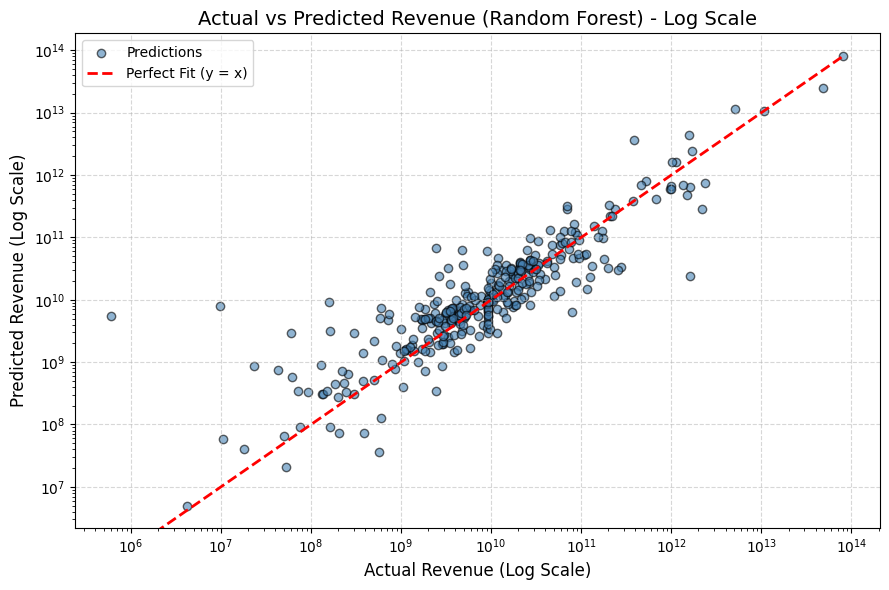

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))
plt.scatter(y_test, best_preds, alpha=0.6, color="steelblue", edgecolors="k", label="Predictions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2, label="Perfect Fit (y = x)")


plt.xscale("log")
plt.yscale("log")

plt.title(f"Actual vs Predicted Revenue ({best_model_name}) - Log Scale", fontsize=14)
plt.xlabel("Actual Revenue (Log Scale)", fontsize=12)
plt.ylabel("Predicted Revenue (Log Scale)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_6223/4009830765.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_imp, x="Importance", y="Feature", palette="viridis")
/tmp/ipykernel_6223/4009830765.py:14: UserWarning: Glyph 54788 (\N{HANGUL SYLLABLE HYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6223/4009830765.py:14: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6223/4009830765.py:14: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6223/4009830765.py:14: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6223/4009830765.py:14: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.

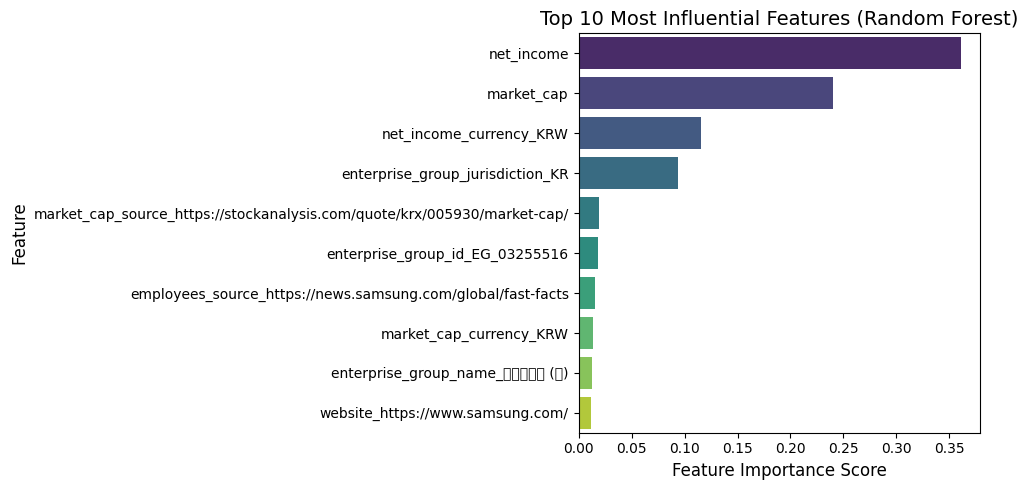

,Feature,Importance
2,net_income,0.360765
4,market_cap,0.240009
8864,net_income_currency_KRW,0.115129
7065,enterprise_group_jurisdiction_KR,0.093678
13954,market_cap_source_https://stockanalysis.com/qu...,0.019197
1535,enterprise_group_id_EG_03255516,0.018725
11028,employees_source_https://news.samsung.com/glob...,0.015886
8898,market_cap_currency_KRW,0.013719
5263,enterprise_group_name_현대자동차 (주),0.012452
8394,website_https://www.samsung.com/,0.011864


In [82]:
import seaborn as sns

if hasattr(best_model, "feature_importances_"):

    importances = best_model.feature_importances_
    feature_imp = pd.DataFrame({"Feature": X.columns, "Importance": importances})
    feature_imp = feature_imp.sort_values(by="Importance", ascending=False).head(10)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=feature_imp, x="Importance", y="Feature", palette="viridis")
    plt.title(f"Top 10 Most Influential Features ({best_model_name})", fontsize=14)
    plt.xlabel("Feature Importance Score", fontsize=12)
    plt.ylabel("Feature", fontsize=12)
    plt.tight_layout()
    plt.show()

    display(feature_imp)

elif hasattr(best_model, "coef_"):

    coef = np.abs(best_model.coef_)
    feature_imp = pd.DataFrame({"Feature": X.columns, "Coefficient": coef})
    feature_imp = feature_imp.sort_values(by="Coefficient", ascending=False).head(10)

    display(feature_imp)

1.Random Forest
It handles non-linear relationships, multi-variable interactions and extreme revenue outliers far better than linear models.

2.R² Score

3.Conglomerates & Holding Companies: Complex structure masks true direct earnings.Mega-Corporations (Top 1%): Few training samples exist at extreme scale.

In [84]:
import pickle


artifacts = {
    "model": model,
    "encoder": encoder,
    "selected_features": selected_features,
    "categorical_features": categorical_features,
    "numerical_features": numerical_features,
}

with open("model_artifacts.pkl", "wb") as f:
    pickle.dump(artifacts, f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [87]:
import pickle



numerical_medians = df[numerical_features].median().to_dict()

artifacts = {
    "model": model,
    "encoder": encoder,
    "selected_features": selected_features,
    "categorical_features": categorical_features,
    "numerical_features": numerical_features,
    "numerical_medians": numerical_medians,
    "target_transform": "log1p"
}

with open("model_artifacts.pkl", "wb") as f:
    pickle.dump(artifacts, f)

In [88]:
from google.colab import files

files.download("model_artifacts.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>